In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import magpylib as magpy

from scipy.spatial.transform import Rotation as R

from atomsmltr.environment import PlaneWaveLaserBeam
from atomsmltr.environment import GaussianLaserBeam
from atomsmltr.environment import ConstantForce
from atomsmltr.atoms import Ytterbium
from atomsmltr.simulation import Configuration, RK4
from atomsmltr.environment import (
    Vertical,
    Horizontal,
    CircularLeft,
    CircularRight,
    Linear,
    Vector,
)
from atomsmltr.environment.fields.magnetic.magpylib import MagpylibWrapper

Simulation 1 from Feb. 19 notion

Text(0, 0.5, 'vz [m/s]')

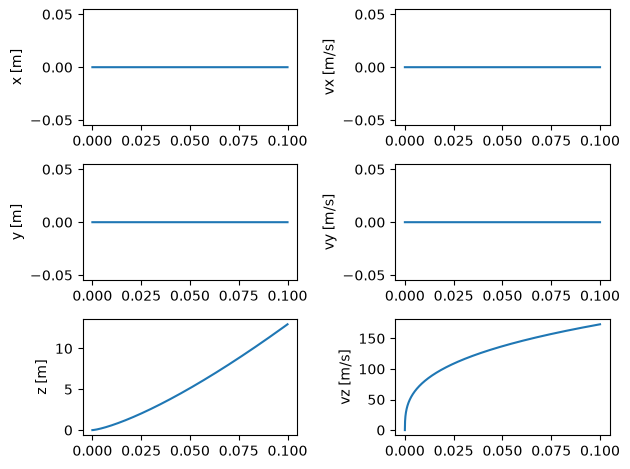

In [6]:
# Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# Push beam
las1 = PlaneWaveLaserBeam(
    wavelength=main.wavelength,
    direction = (0,0,1),
    waist_position=(0,0,-2)
)

las1.set_power_from_I(main.Isat)
las1.tag = "GreenPush"


# Config 
config = Configuration()
config.atom = atom
config += las1

#Add coupling between the push beam and the main transition of the atom
config.add_atomlight_coupling(las1, 'main', 0)

# Sim
sim = RK4(config = config)
t = np.linspace(0,0.1,6000)
u0 = (0,0,0,0,0,0)

res = sim.integrate(u0, t)

# Plotting
fig, ax = plt.subplots(3, 2, tight_layout = True)

#Positions
ax[0,0].plot(t, res.y[0])
ax[0,0].set_ylabel("x [m]")

ax[1,0].plot(t, res.y[1])
ax[1,0].set_ylabel("y [m]")

ax[2,0].plot(t, res.y[2])
ax[2,0].set_ylabel("z [m]")

#Velocities
ax[0,1].plot(t, res.y[3])
ax[0,1].set_ylabel("vx [m/s]")

ax[1,1].plot(t, res.y[4])
ax[1,1].set_ylabel("vy [m/s]")

ax[2,1].plot(t, res.y[5])
ax[2,1].set_ylabel("vz [m/s]")


Trial #3 on Feb. 19 Notion

Text(0, 0.5, 'vz [m/s]')

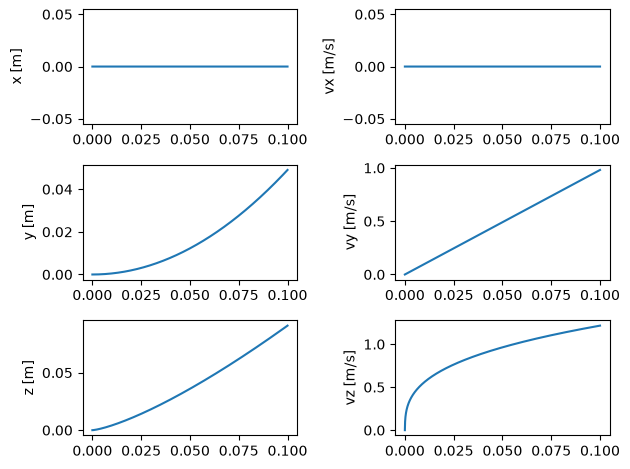

In [3]:
# Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# Push beam
las1 = PlaneWaveLaserBeam(
    wavelength=inter.wavelength,
    direction = (0,0,1),
    waist_position=(0,0,-2)
)

las1.set_power_from_I(inter.Isat)
las1.tag = "GreenPush"

#Gravity
m = Ytterbium().mass
g = 9.81
gravity = ConstantForce(field_value = (0,m*g, 0), tag="gravity")

# Config 
config = Configuration()
config.atom = atom
config += las1, gravity

#Add coupling between the push beam and the main transition of the atom
config.add_atomlight_coupling(las1, 'intercombination', 0)



# Sim
sim = RK4(config = config)
t = np.linspace(0,0.1,6000)
u0 = (0,0,0,0,0,0)

res = sim.integrate(u0, t)

# Plotting
fig, ax = plt.subplots(3, 2, tight_layout = True)

#Positions
ax[0,0].plot(t, res.y[0])
ax[0,0].set_ylabel("x [m]")

ax[1,0].plot(t, res.y[1])
ax[1,0].set_ylabel("y [m]")

ax[2,0].plot(t, res.y[2])
ax[2,0].set_ylabel("z [m]")

#Velocities
ax[0,1].plot(t, res.y[3])
ax[0,1].set_ylabel("vx [m/s]")

ax[1,1].plot(t, res.y[4])
ax[1,1].set_ylabel("vy [m/s]")

ax[2,1].plot(t, res.y[5])
ax[2,1].set_ylabel("vz [m/s]")

Sweeping 3D MOT beam diameter and intensity 

In [16]:
#Init fixed elements

# ------------- Atom
atom = Ytterbium()

main = atom.trans["main"]
inter = atom.trans["intercombination"]

# ------------- Green Push beam
las1 = GaussianLaserBeam(
    wavelength=inter.wavelength,
    waist = 2e-3,
    waist_position = (0,0,-2),
    direction = (0,0,1)
)

las1.set_power_from_I(inter.Isat)
las1.polarization = Vertical()
las1.tag = "las1"

# ------------- 2D MOT B-field
Br = 1.42
mu0 = 4*np.pi*1e-7
M = Br/(mu0)

magnet_1 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_2 = magpy.magnet.Cuboid(
    position = (-5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, M))
magnet_3 = magpy.magnet.Cuboid(
    position = (5.3*0.01, -4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))
magnet_4 = magpy.magnet.Cuboid(
    position = (5.3*0.01, 4*0.01, 0), dimension = (2*0.01, 2*0.01, 5.5*0.01), magnetization = (0, 0, -M))

magnets = magpy.Collection(magnet_1, magnet_2, magnet_3, magnet_4)

# Rotate so the extraction axis points UP (+z)
rot = R.from_euler('x', 90, degrees=True)
magnets.rotate(rot, anchor=(0, 0, 0))

# Shift the whole 2D MOT assembly 20 cm below the 3D MOT chamber center
magnets.move((0, 0, -0.2))

# wrap it up
mag_field_2D_MOT = MagpylibWrapper(magnets)
mag_field_2D_MOT.tag = "2D MOT coils"

# ------------- 3D MOT B-field
def mot3d_coil(I=35, config="AH", plot_obj=False):

    if config=="H":
        curr_up = -I
        curr_down = -I
    else:
        if config=="AH":
            curr_up = I
            curr_down = -I
        else:
            raise ValueError("Invalid 3D MOT Coil Configuration")

    # Turns
    T = 3
    # Windings
    W = 2

    # Spacing between windings
    s = 1.37 * 0.001 # in mm

    # Diameter
    # d - Inner diameter
    d = 66.167 * 0.001 # in mm

    # Error
    e = 0 # in mm

    # Position of coils
    z_1 = 17.78 * 0.001 + e
    z_2 = -z_1

    coil = magpy.Collection()

    # Note: Unlike the cavity coil function, the 3D MOT function starts populating turns from the bottom of the top coil, and the top of the bottom coil.

    for i in range(0, T):
        for n in range(W):

            # Upper Coils
            winding1 = magpy.current.Circle(
                current = curr_up,
                diameter = d + (2*n + 1) * s,
                position = (0, 0, z_1 + i*s),
            )

            coil.add(winding1)

            # Lower Coils
            winding2 = magpy.current.Circle(
                current = curr_down,
                diameter = d + (2*n + 1) * s,
                position = (0, 0, z_2 - i*s),
            )

            coil.add(winding2)

    if plot_obj:
        coil.show(backend='plotly')

    return coil

motcoil = mot3d_coil(config="AH", plot_obj=False)

# ROTATION: Rotate the 3D MOT coils if needed
# For example, rotating 90 degrees around the X-axis 
# (This would flip the coil symmetry axis from the Z-axis to the Y-axis)
rot_3d_mot = R.from_euler('x', 90, degrees=True)
motcoil.rotate(rot_3d_mot, anchor=(0, 0, 0))

# wrap it up
mag_field_3D_MOT = MagpylibWrapper(motcoil)
mag_field_3D_MOT.tag = "3D MOT coils"

# ------------- Gravity
m = Ytterbium().mass
g = 9.81
gravity = ConstantForce(field_value = (0, 0, -m*g), tag="gravity")




In [ ]:
# Modifying 3D MOT laser setup

# ------------- 3D MOT lasers 

resList = []
intensityList = [1]
intensityList = [x * inter.Isat for x in intensityList]
waistList = [2,4,6,8]
waistList = [x * 1e-3 for x in waistList]

for waist in waistList:
    # Create the 6 beams for a 3D MOT
    # 1 & 2: Vertical Pair (+z, -z)
    las_z_up = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(0,0,1))
    las_z_down = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(0,0,-1))

    # 3 & 4: Horizontal Pair 1 (+x, -x)
    las_x_plus = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(1,0,0))
    las_x_minus = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(-1,0,0))

    # 5 & 6: Horizontal Pair 2 (+y, -y)
    las_y_plus = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(0,1,0))
    las_y_minus = GaussianLaserBeam(wavelength=inter.wavelength, waist=waist, waist_position=(0, 0, 0), direction=(0,-1,0))

    # Set power (can increase if we want power broadening)
    las_z_up.set_power_from_I(5 * inter.Isat)
    las_z_down.set_power_from_I(5 * inter.Isat)
    las_x_plus.set_power_from_I(5 * inter.Isat)
    las_x_minus.set_power_from_I(5 * inter.Isat)
    las_y_plus.set_power_from_I(5 * inter.Isat)
    las_y_minus.set_power_from_I(5 * inter.Isat)

    # Assign Polarizations (Must be Circular and match the anti-Helmholtz field signs!)
    las_z_up.polarization = CircularRight()
    las_z_down.polarization = CircularRight()
    las_x_plus.polarization = CircularRight()
    las_x_minus.polarization = CircularRight()
    las_y_plus.polarization = CircularLeft()
    las_y_minus.polarization = CircularLeft()

    # Tag them for coupling identification
    las_z_up.tag = "z_up"; las_z_down.tag = "z_down"
    las_x_plus.tag = "x_plus"; las_x_minus.tag = "x_minus"
    las_y_plus.tag = "y_plus"; las_y_minus.tag = "y_minus"

    # ------------- Configuration
    config = Configuration()
    config.atom = atom
    config += las1, gravity, mag_field_3D_MOT, mag_field_2D_MOT
    config += las_z_up, las_z_down, las_x_plus, las_x_minus, las_y_plus, las_y_minus

    # # Set a red-detuning relative to the intercombination transition
    detuning_push = 0
    config.add_atomlight_coupling("las1", "intercombination", detuning_push) # Arguments: laser = "las1", transition = intercombination", detuning = detuning_push

    # Tie all 6 lasers to the intercombination transition simultaneously
    detuning_3D_mot = -inter.Gamma/2 # red-detuning for trapping
    for tag in ["z_up", "z_down", "x_plus", "x_minus", "y_plus", "y_minus"]:
        config.add_atomlight_coupling(tag, "intercombination", detuning_3D_mot)

    # - simulation
    sim = RK4(config=config)
    t = np.linspace(0, 2, 6000) # timesteps for integration
    u0 = (0, 0, -0.2, 0, 0, 0) # atom starts with z = -0.2 m (20 cm below the 3D MOT center) and zero velocity
    resList.append(sim.integrate(u0, t))




<function matplotlib.pyplot.show(close=None, block=None)>

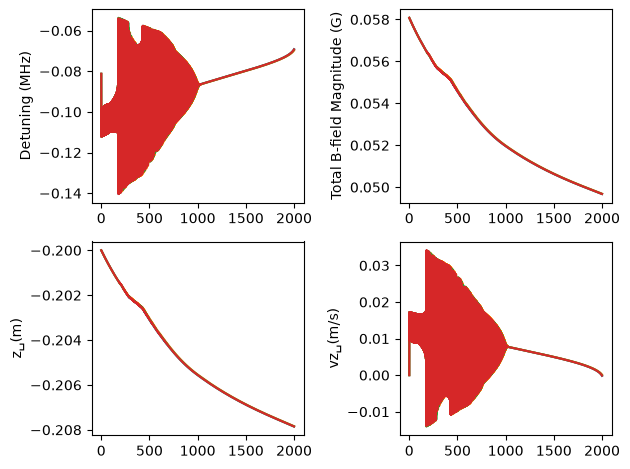

In [25]:
# Plot results
fig, ax = plt.subplots(2, 2, tight_layout = True)

mu_B = 9.274e-24
hbar = 1.055e-34
gJ = 1  # depends on state!
mJ = -1  # choose a sublevel

for i, waist in enumerate(waistList):
    res = resList[i]

    positions = res.y[:3].T
    B_total = mag_field_2D_MOT.get_value(positions) + mag_field_3D_MOT.get_value(positions)
    B_mag = np.linalg.norm(B_total, axis=1)

    zeeman = (mu_B * gJ * mJ / hbar) * B_mag
    doppler = -(2 * np.pi / inter.wavelength) * res.y[5]

    ax[0, 0].plot(res.t * 1e3, (doppler+zeeman)/(2*np.pi*1e6))
    ax[0, 0].set_ylabel("Detuning (MHz)")
    ax[0, 1].plot(res.t * 1e3, B_mag * 1e4)
    ax[0, 1].set_ylabel("Total B-field Magnitude (G)")

    ax[1, 0].plot(res.t * 1e3, res.y[2])
    ax[1, 0].set_ylabel("z␣(m)")
    ax[1, 1].plot(res.t * 1e3, res.y[5])
    ax[1, 1].set_ylabel("vz␣(m/s)")

plt.show